### Download a Google Drive file by ID

To download a specific file from Google Drive using its ID, you can use the `gdown` library. You'll need to extract the file ID from the sharing link.

In [3]:
!pip install gdown

# The file ID is the part after 'id/' in the URL
# For your link 'https://drive.google.com/file/d/1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm/view?usp=sharing',
# the file ID is '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'

gdrive_file_id = '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'
output_filename = 'monreader_data.zip' # Or whatever the file type is, e.g., 'data.zip'

!gdown --id {gdrive_file_id} -O {output_filename}

print(f"File '{output_filename}' downloaded to your Colab environment.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm
From (redirected): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm&confirm=t&uuid=8732f5d3-83a1-49e6-af47-b0266358094a
To: /content/monreader_data.zip
100% 940M/940M [00:11<00:00, 82.0MB/s]
File 'monreader_data.zip' downloaded to your Colab environment.


In [4]:
import zipfile

with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')
print(f"Extracted '{output_filename}' to 'extracted_folder'.")

Extracted 'monreader_data.zip' to 'extracted_folder'.


### Data Exploration: Image Counts, Dimensions, and Samples

Let's start by exploring the extracted dataset to understand its structure. We'll count the number of images in each category (flip/notflip), examine their dimensions, and display a few sample images.

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

base_dir = 'extracted_folder/images/training'
notflip_dir = os.path.join(base_dir, 'notflip')
flip_dir = os.path.join(base_dir, 'flip')

# --- 1. Count images ---
notflip_images_training = [os.path.join(notflip_dir, f) for f in os.listdir(notflip_dir) if f.endswith(('.jpg'))]
flip_images_training = [os.path.join(flip_dir, f) for f in os.listdir(flip_dir) if f.endswith(('.jpg'))]

print(f"Number of 'notflip' images: {len(notflip_images_training)}")
print(f"Number of 'flip' images: {len(flip_images_training)}")
print(f"Total images: {len(notflip_images_training) + len(flip_images_training)}")

Number of 'notflip' images: 1230
Number of 'flip' images: 1162
Total images: 2392


In [6]:
from PIL import Image
# --- 2. Check image dimensions ---
notflip_image_path = notflip_images_training[0]
with Image.open(notflip_image_path) as notflip_image:
 print(f"\nSample image dimensions (notflip image size): {notflip_image.size} (width, height)")
 print(f"Sample image mode: {notflip_image.mode}") # e.g., RGB, L
 flip_image_path = flip_images_training[0]
with Image.open(flip_image_path) as flip_image:
 print(f"\nSample image dimensions (flip image size): {flip_image.size} (width, height)")
 print(f"Sample image mode: {flip_image.mode}") # e.g., RGB, L


Sample image dimensions (notflip image size): (1080, 1920) (width, height)
Sample image mode: RGB

Sample image dimensions (flip image size): (1080, 1920) (width, height)
Sample image mode: RGB



Displaying sample images...


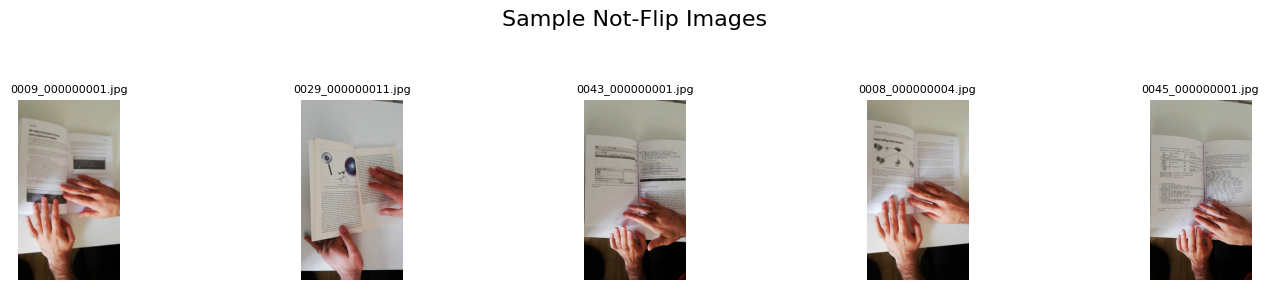

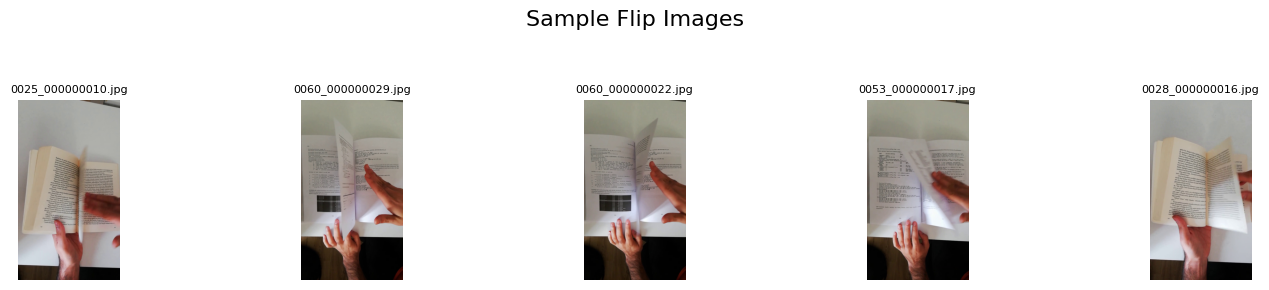

In [7]:
# --- 3. Display sample images ---
print("\nDisplaying sample images...")

def display_samples(image_paths, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(np.random.choice(image_paths, num_samples, replace=False)):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

if notflip_images_training:
    display_samples(notflip_images_training, 'Sample Not-Flip Images')

if flip_images_training:
    display_samples(flip_images_training, 'Sample Flip Images')


### Build a Custom PyTorch `ImageDataset`

To prepare the image data for a PyTorch model, we need to create a custom `Dataset` class. This class will:

1.  **Inherit from `torch.utils.data.Dataset`**: This provides the base functionality for PyTorch datasets.
2.  **`__init__(self, root_dir, transform=None)`**: This constructor will initialize the dataset. It will scan the `root_dir` (e.g., `extracted_folder/images/training`) to find image paths and their corresponding labels based on the subfolder names (`notflip`, `flip`). It also accepts an optional `transform` function to apply data augmentations or preprocessing.
3.  **`__len__(self)`**: This method will return the total number of images in the dataset.
4.  **`__getitem__(self, idx)`**: This is the core method. Given an index `idx`, it will load the image at that index, apply any specified transformations, and return the image tensor along with its numerical label.

In [8]:
import torch
from torchvision import transforms, datasets # Added datasets
import os
from PIL import Image

# The custom MonReaderDataset class has been removed as requested

# Example usage:
# Define a transformation (e.g., resize, convert to tensor)
# This is a basic transformation, more complex ones can be added later.
preprocess_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize images to a common size
    transforms.ToTensor(),         # Convert PIL Image to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize as typically done for pre-trained models
])

# Use ImageFolder for simplified dataset creation, automatically labeling 'flip' and 'notflip'
train_dataset = datasets.ImageFolder(root='extracted_folder/images/training', transform=preprocess_transform)
test_dataset = datasets.ImageFolder(root='extracted_folder/images/testing', transform=preprocess_transform)

print(f"Training dataset size: {len(train_dataset)}")

print(f"Testing dataset size: {len(test_dataset)}")

# Access a sample item
sample_image, sample_label = train_dataset[22]
print(f"Sample image tensor shape: {sample_image.shape}")
print(f"Sample label: {sample_label} (which corresponds to class: {train_dataset.classes[sample_label]})")

Training dataset size: 2392
Testing dataset size: 597
Sample image tensor shape: torch.Size([3, 224, 224])
Sample label: 0 (which corresponds to class: flip)


In [9]:
# Assuming 'train_dataset' has been created and is available from a previous cell.
# Get class names and their corresponding integer labels from the dataset.
class_to_idx = train_dataset.class_to_idx

# Get the integer label for 'flip' and 'notflip' classes
flip_label_idx = class_to_idx.get('flip')
notflip_label_idx = class_to_idx.get('notflip')

# Count occurrences of each label in the training dataset targets
train_flip_count = sum(1 for label in train_dataset.targets if label == flip_label_idx)
train_notflip_count = sum(1 for label in train_dataset.targets if label == notflip_label_idx)

print(f"Training Dataset Distribution:")
print(f"  Flip images: {train_flip_count}")
print(f"  Not-flip images: {train_notflip_count}")
print(f"  Total training images: {len(train_dataset)}")

Training Dataset Distribution:
  Flip images: 1162
  Not-flip images: 1230
  Total training images: 2392


In [10]:
import numpy as np

# Extract X_train and y_train from train_dataset
X_train_list = []
y_train_list = []
for img, label in train_dataset:
    X_train_list.append(img.numpy())  # Convert image tensor to numpy array
    y_train_list.append(label)       # Labels are already Python integers
X_train = np.stack(X_train_list)
y_train = np.array(y_train_list)

# Extract X_test and y_test from test_dataset
X_test_list = []
y_test_list = []
for img, label in test_dataset:
    X_test_list.append(img.numpy())   # Convert image tensor to numpy array
    y_test_list.append(label)         # Labels are already Python integers
X_test = np.stack(X_test_list)
y_test = np.array(y_test_list)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (2392, 3, 224, 224), y_train shape: (2392,)
X_test shape: (597, 3, 224, 224), y_test shape: (597,)


In [14]:
X_train= X_train.reshape(-1, 224, 224, 3)
y_train= y_train.reshape(-1, 1)
X_test= X_test.reshape(-1, 224, 224, 3)
y_test= y_test.reshape(-1, 1)

In [22]:
print(X_train.shape)
print(y_train.shape)

(2392, 224, 224, 3)
(2392, 1)


In [15]:
X_train[1,:]

array([[[ 0.3651854 ,  0.34806067,  0.33093593],
        [ 0.33093593,  0.33093593,  0.31381115],
        [ 0.31381115,  0.2966864 ,  0.27956167],
        ...,
        [ 0.4850587 ,  0.50218344,  0.46793392],
        [ 0.45080918,  0.41655967,  0.41655967],
        [ 0.45080918,  0.45080918,  0.45080918]],

       [[ 0.33093593,  0.31381115,  0.31381115],
        [ 0.31381115,  0.31381115,  0.2966864 ],
        [ 0.2966864 ,  0.31381115,  0.33093593],
        ...,
        [ 0.50218344,  0.50218344,  0.50218344],
        [ 0.4850587 ,  0.4850587 ,  0.50218344],
        [ 0.50218344,  0.5193082 ,  0.5364329 ]],

       [[ 0.31381115,  0.31381115,  0.2624369 ],
        [ 0.2624369 ,  0.2624369 ,  0.2624369 ],
        [ 0.2624369 ,  0.2281874 ,  0.2624369 ],
        ...,
        [ 0.50218344,  0.46793392,  0.50218344],
        [ 0.50218344,  0.50218344,  0.4850587 ],
        [ 0.4850587 ,  0.4850587 ,  0.4850587 ]],

       ...,

       [[-1.7521569 , -1.7521569 , -1.7521569 ],
        [-1

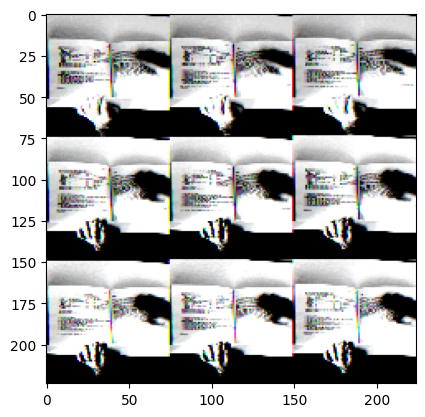

In [23]:
import random
idx= random.randint(0, len(X_train))
plt.imshow(X_train[idx,:])
plt.show()

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model= Sequential()
model.add(Conv2D(64, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 338s 4s/step - accuracy: 0.8169 - loss: 0.6658
Epoch 2/10
11/75 ━━━━━━━━━━━━━━━━━━━━ 4:36 4s/step - accuracy: 0.9636 - loss: 0.1231

KeyboardInterrupt: 